In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
from PIL import Image
import json
import shutil
import os
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import random
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import transforms, models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
kaggle_token = {
    "username": "sriyavemuri",
    "key": "KGAT_e3097dc7ceaf657160cb4f60e802cdf3"
}

with open('kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

In [4]:
for item in os.listdir('/content'):
    item_path = os.path.join('/content', item)
    try:
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.remove(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
    except Exception as e:
        print(f"Failed to delete {item_path}: {e}")

In [5]:
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip -q celeba-dataset.zip -d /content/celeba/
!unzip -q /content/celeba/img_align_celeba.zip -d /content/celeba/img_align_celeba/

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:19<00:00, 74.7MB/s]

unzip:  cannot find or open /content/celeba/img_align_celeba.zip, /content/celeba/img_align_celeba.zip.zip or /content/celeba/img_align_celeba.zip.ZIP.


In [ ]:
os.listdir('/content/celeba')

['list_bbox_celeba.csv',
 'list_eval_partition.csv',
 'img_align_celeba',
 'list_attr_celeba.csv',
 'list_landmarks_align_celeba.csv']

Configuration

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ATTR_PATH = "/content/celeba/list_attr_celeba.csv"
IMG_DIR = "/content/celeba/img_align_celeba/img_align_celeba"

STRUCTURAL_COLS = [
    "Arched_Eyebrows", "Bags_Under_Eyes", "Big_Lips", "Big_Nose",
    "Bushy_Eyebrows", "High_Cheekbones", "Narrow_Eyes",
    "Oval_Face", "Pointy_Nose", "Rosy_Cheeks"
]
MAKEUP_COLS = ["Heavy_Makeup", "Wearing_Lipstick"]
METRIC_COL = "Style_Rating"

Local Engine - Calculating scores for 3 states

In [ ]:
def build_style_engine(df):
    engine_stats = {}
    for feature in STRUCTURAL_COLS:
        subset = df[df[feature] == 1]
        if len(subset) < 10:
            continue

        natural = subset[(subset['Heavy_Makeup'] == 0) & (subset['Wearing_Lipstick'] == 0)]
        lips    = subset[(subset['Heavy_Makeup'] == 0) & (subset['Wearing_Lipstick'] == 1)]
        glam    = subset[(subset['Heavy_Makeup'] == 1)]

        engine_stats[feature] = {
            "Natural":   natural[METRIC_COL].mean() if len(natural) > 0 else 0,
            "Lip_Focus": lips[METRIC_COL].mean()    if len(lips)    > 0 else 0,
            "Full_Glam": glam[METRIC_COL].mean()    if len(glam)    > 0 else 0,
        }
    return engine_stats

Data Loading and Weights

In [ ]:
def load_and_prep_data(attr_path, img_dir, subset_size=60000):
    if not os.path.exists(attr_path):
        return pd.DataFrame()

    attr_df = pd.read_csv(attr_path)

    if "image_id" in attr_df.columns:
        attr_df.rename(columns={"image_id": "filename"}, inplace=True)

    if "Attractive" in attr_df.columns and METRIC_COL not in attr_df.columns:
        attr_df.rename(columns={"Attractive": METRIC_COL}, inplace=True)

    # Mapping -1/1 to 0/1 for all columns
    for col in STRUCTURAL_COLS + MAKEUP_COLS + [METRIC_COL]:
        if attr_df[col].min() < 0:
            attr_df[col] = (attr_df[col].astype(int) + 1) // 2

    attr_df["img_path"] = attr_df["filename"].apply(
        lambda x: os.path.join(img_dir, x)
    )

    if len(attr_df) > subset_size:
        attr_df = attr_df.sample(n=subset_size, random_state=SEED).reset_index(drop=True)

    return attr_df

In [ ]:
df = load_and_prep_data(ATTR_PATH, IMG_DIR)
STYLE_ENGINE = build_style_engine(df)
train_df, val_df = train_test_split(df, test_size=0.15, random_state=SEED)

print("\n Calculating 'Damped' Class Weights")
# 1. Count positives
pos_counts = train_df[STRUCTURAL_COLS].sum().values
total = len(train_df)
# 2. Calculate Raw Weight: (Total / Pos)
raw_weights = (total - pos_counts) / (pos_counts + 1e-5)
# 3. Apply Square Root (Damping)
damped_weights = np.sqrt(raw_weights)
pos_weights = torch.tensor(damped_weights, dtype=torch.float32).to(DEVICE)

print(f"{'Feature':<20} | {'Raw W':<6} | {'Damped W (Used)':<15}")
print("-" * 45)
for i, col in enumerate(STRUCTURAL_COLS):
    print(f"{col:<20} | {raw_weights[i]:.1f}x   | {damped_weights[i]:.2f}x")



 Calculating 'Damped' Class Weights
Feature              | Raw W  | Damped W (Used)
---------------------------------------------
Arched_Eyebrows      | 2.8x   | 1.67x
Bags_Under_Eyes      | 3.9x   | 1.97x
Big_Lips             | 3.2x   | 1.78x
Big_Nose             | 3.3x   | 1.81x
Bushy_Eyebrows       | 5.9x   | 2.44x
High_Cheekbones      | 1.2x   | 1.10x
Narrow_Eyes          | 7.7x   | 2.78x
Oval_Face            | 2.5x   | 1.58x
Pointy_Nose          | 2.6x   | 1.61x
Rosy_Cheeks          | 14.1x   | 3.75x


Data Augmentation

In [ ]:
class FeatureDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        labels = torch.tensor(row[STRUCTURAL_COLS].values.astype("float32"))
        return image, labels

IMG_SIZE = 128
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_loader = DataLoader(
    FeatureDataset(train_df, train_transform),
    batch_size=64,
    shuffle=True,
    num_workers=2,
)
val_loader = DataLoader(
    FeatureDataset(val_df, val_transform),
    batch_size=64,
    shuffle=False,
    num_workers=2,
)

ResNet50 Model

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(STRUCTURAL_COLS)),
)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Train Model

In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_detailed(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model(imgs)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
            all_preds.append(preds)
            all_labels.append(lbls.cpu().numpy())

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_labels)

    micro_f1 = f1_score(y_true, y_pred, average="micro")
    per_class_f1 = f1_score(y_true, y_pred, average=None)
    return micro_f1, per_class_f1

num_epochs = 6
for epoch in range(num_epochs):
    loss = train_epoch(model, train_loader)
    val_f1, class_f1s = evaluate_detailed(model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f} | Overall F1: {val_f1:.4f}")

    if (epoch + 1) % 2 == 0:
        print(" > Per-Feature Accuracy (F1):")
        for i, col in enumerate(STRUCTURAL_COLS):
            print(f"   - {col:<15}: {class_f1s[i]:.2f}")

Epoch 1/6 | Loss: 0.3589 | Overall F1: 0.6500
Epoch 2/6 | Loss: 0.3271 | Overall F1: 0.6473
 > Per-Feature Accuracy (F1):
   - Arched_Eyebrows: 0.73
   - Bags_Under_Eyes: 0.62
   - Big_Lips       : 0.50
   - Big_Nose       : 0.63
   - Bushy_Eyebrows : 0.69
   - High_Cheekbones: 0.85
   - Narrow_Eyes    : 0.51
   - Oval_Face      : 0.52
   - Pointy_Nose    : 0.56
   - Rosy_Cheeks    : 0.63
Epoch 3/6 | Loss: 0.2933 | Overall F1: 0.6370
Epoch 4/6 | Loss: 0.2624 | Overall F1: 0.6332
 > Per-Feature Accuracy (F1):
   - Arched_Eyebrows: 0.71
   - Bags_Under_Eyes: 0.58
   - Big_Lips       : 0.48
   - Big_Nose       : 0.62
   - Bushy_Eyebrows : 0.67
   - High_Cheekbones: 0.85
   - Narrow_Eyes    : 0.46
   - Oval_Face      : 0.53
   - Pointy_Nose    : 0.55
   - Rosy_Cheeks    : 0.61
Epoch 5/6 | Loss: 0.2351 | Overall F1: 0.6334
Epoch 6/6 | Loss: 0.2103 | Overall F1: 0.6286
 > Per-Feature Accuracy (F1):
   - Arched_Eyebrows: 0.68
   - Bags_Under_Eyes: 0.58
   - Big_Lips       : 0.48
   - Big_Nose

Recommender

In [ ]:
def recommend_look(model, image_path, engine):
    if not os.path.exists(image_path):
        return

    model.eval()
    image = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        preds = torch.sigmoid(model(img_tensor))[0]

    print(f"\nAnalysis for: {os.path.basename(image_path)}")
    detected_features = []

    threshold = 0.50

    for i, feature in enumerate(STRUCTURAL_COLS):
        conf = preds[i].item()
        if conf > threshold:
            print(f" > Detected: {feature} ({conf:.1%})")
            detected_features.append(feature)

    scores = {"Natural": 0, "Lip_Focus": 0, "Full_Glam": 0}
    count = 0
    for feature in detected_features:
        if feature in engine:
            stats = engine[feature]
            scores["Natural"]   += stats["Natural"]
            scores["Lip_Focus"] += stats["Lip_Focus"]
            scores["Full_Glam"] += stats["Full_Glam"]
            count += 1

    if count > 0:
        for k in scores:
            scores[k] /= count
    else:
        scores = {"Natural": 0.40, "Lip_Focus": 0.50, "Full_Glam": 0.60}

    print("\nPredicted Style Rating by Look:")
    print(f" 1. Natural:   {scores['Natural']:.1%}")
    print(f" 2. Lip Focus: {scores['Lip_Focus']:.1%}")
    print(f" 3. Full Glam: {scores['Full_Glam']:.1%}")

    best_style = max(scores, key=scores.get)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Best: {best_style}", color="green", fontweight="bold")
    plt.show()



Test


Analysis for: nomake.jpg
 > Detected: Big_Lips (93.0%)
 > Detected: Pointy_Nose (68.4%)

Predicted Style Rating by Look:
 1. Natural:   33.0%
 2. Lip Focus: 58.0%
 3. Full Glam: 81.6%


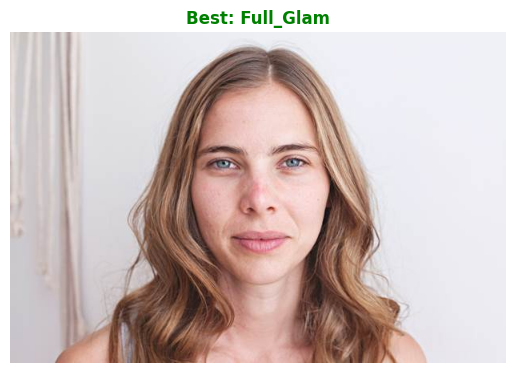

In [ ]:
recommend_look(model, "/content/nomake.jpg", STYLE_ENGINE)



Analysis for: messy-makeup-.png
 > Detected: Arched_Eyebrows (63.1%)
 > Detected: Bags_Under_Eyes (64.2%)
 > Detected: Pointy_Nose (76.6%)

Predicted Style Rating by Look:
 1. Natural:   34.2%
 2. Lip Focus: 56.1%
 3. Full Glam: 80.1%


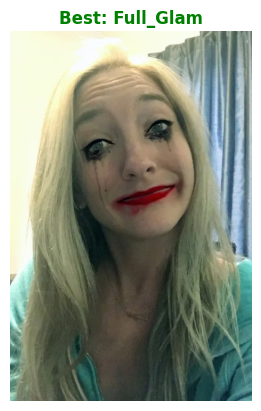

In [ ]:
recommend_look(model, "/content/messy-makeup-.png", STYLE_ENGINE)



 ANALYSIS FOR: nomake.jpg
 (Path: /content/nomake.jpg)             
--------------------------------------------------
DETECTED STRUCTURAL FEATURES:
  [x] Big_Lips             (Confidence: 93.0%)
  [x] Pointy_Nose          (Confidence: 68.4%)
--------------------------------------------------
PREDICTED STYLE :
  1. Natural Look:   33.0%
  2. Lip Focus:      58.0%
  3. Full Glam:      81.6%

>>> FINAL RECOMMENDATION: FULL GLAM


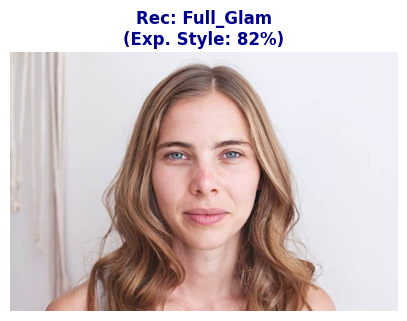


 ANALYSIS FOR: messy-makeup-.png
 (Path: /content/messy-makeup-.png)      
--------------------------------------------------
DETECTED STRUCTURAL FEATURES:
  [x] Arched_Eyebrows      (Confidence: 63.1%)
  [x] Bags_Under_Eyes      (Confidence: 64.2%)
  [x] Pointy_Nose          (Confidence: 76.6%)
--------------------------------------------------
PREDICTED STYLE :
  1. Natural Look:   34.2%
  2. Lip Focus:      56.1%
  3. Full Glam:      80.1%

>>> FINAL RECOMMENDATION: FULL GLAM


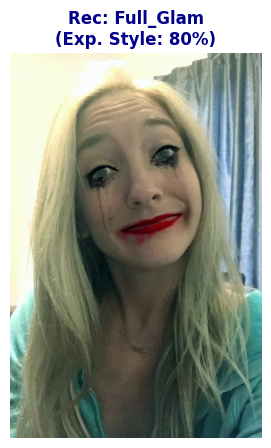

In [ ]:

test_image_paths = [
    "/content/nomake.jpg",
    "/content/messy-makeup-.png",
]

def test_batch_images(model, image_paths, engine):
    model.eval()
    threshold = 0.50

    for img_path in image_paths:
        if not os.path.exists(img_path):
            print(f"\n[Skipping] File not found: {img_path}")
            continue

        try:
            image = Image.open(img_path).convert("RGB")
            img_tensor = val_transform(image).unsqueeze(0).to(DEVICE)

            # Predicting Features
            with torch.no_grad():
                preds = torch.sigmoid(model(img_tensor))[0]

            # Analyzing Features
            detected_features = []
            print(f"\n" + "="*50)
            print(f" ANALYSIS FOR: {os.path.basename(img_path)}")
            print(f" {'(Path: ' + img_path + ')':<40}")
            print("-" * 50)

            print("DETECTED STRUCTURAL FEATURES:")
            for i, feature in enumerate(STRUCTURAL_COLS):
                conf = preds[i].item()
                if conf > threshold:
                    print(f"  [x] {feature:<20} (Confidence: {conf:.1%})")
                    detected_features.append(feature)

            if not detected_features:
                print("  [ ] No distinct features detected.")

            scores = {"Natural": 0, "Lip_Focus": 0, "Full_Glam": 0}
            count = 0

            for feature in detected_features:
                if feature in engine:
                    stats = engine[feature]
                    scores["Natural"] += stats["Natural"]
                    scores["Lip_Focus"] += stats["Lip_Focus"]
                    scores["Full_Glam"] += stats["Full_Glam"]
                    count += 1

            # Normalizing scores
            if count > 0:
                for k in scores: scores[k] /= count
            else:
                scores = {"Natural": 0.4, "Lip_Focus": 0.5, "Full_Glam": 0.6}

            best_style = max(scores, key=scores.get)
            best_score = scores[best_style]

            print("-" * 50)
            print("PREDICTED STYLE :")
            print(f"  1. Natural Look:   {scores['Natural']:.1%}")
            print(f"  2. Lip Focus:      {scores['Lip_Focus']:.1%}")
            print(f"  3. Full Glam:      {scores['Full_Glam']:.1%}")

            print(f"\n>>> FINAL RECOMMENDATION: {best_style.replace('_', ' ').upper()}")


            plt.figure(figsize=(5, 5))
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Rec: {best_style}\n(Exp. Style: {best_score:.0%})",
                      fontsize=12, color='darkblue', fontweight='bold')
            plt.show()

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

test_batch_images(model, test_image_paths, STYLE_ENGINE)

Saving model


In [ ]:
torch.save(model.state_dict(), 'checkpoint.pth')

In [ ]:
state_dict = torch.load('checkpoint.pth')
print(state_dict.keys())

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.0.conv3.weight', 'layer1.0.bn3.weight', 'layer1.0.bn3.bias', 'layer1.0.bn3.running_mean', 'layer1.0.bn3.running_var', 'layer1.0.bn3.num_batches_tracked', 'layer1.0.downsample.0.weight', 'layer1.0.downsample.1.weight', 'layer1.0.downsample.1.bias', 'layer1.0.downsample.1.running_mean', 'layer1.0.downsample.1.running_var', 'layer1.0.downsample.1.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.we